In [22]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
plt.style.use('ggplot')


# Global Health Stats

 The purpose of this notebook is to explore my findings to hypothetical questions that I have asked. 

 My desire is to: 
 - Grow in my skills as a disease tracker and data visualizer
 - Investigate the prevalence and incidence rates of global diseases
 - Explain my results in a way that can influence policies 

My dataset was retrieved from [Kaggle.com](https://www.kaggle.com/datasets/malaiarasugraj/global-health-statistics). The CSV file was downloaded and imported into a SQLite database, and a connection was made to retrieve data directly from the database. Let's get started!

## Step 1: Get Data
Set up SQLite database connection and assign the dataset to its own variable for ease of reuse.

In [23]:
db_path = 'new-db.db'
conn = sqlite3.connect(db_path)

Before tackling the first question, I created the temporary table 'staging_table' that retrieves all the data used to answer the first few questions.

In [24]:
staging_table = """
SELECT * 
FROM StagingHealthData
;
"""

## Step 2: Question 1
What is the incidence rate of the top 5 diseases in the past 10 years (2014-2024) ?

Create another temporary table to display the top five diseases.

Use a function called 'read_sql' to read the SQL database table into a DataFrame. 

In [25]:
top_dis_table = """
SELECT *
FROM Top_Diseases
;
"""
df_staging = pd.read_sql(staging_table, conn)
df_top_diseases = pd.read_sql(top_dis_table, conn)


Break up the code here with some text

In [26]:
df_q1_result = (
    df_staging.merge(
        df_top_diseases, 
        on='Disease_Name', 
        how='inner' 
    )   
    .query('2015 <= Year <= 2025')    
    .groupby(['Disease_Name', 'Year'])['Incidence_Rate']
    .mean()   
    .reset_index(name='Average_Incidence_Rate')    
    .sort_values(by=['Disease_Name', 'Year'], ascending=[True, True])
)
print(df_q1_result)

           Disease_Name  Year  Average_Incidence_Rate
0              COVID-19  2015                7.488977
1              COVID-19  2016                7.511204
2              COVID-19  2017                7.501294
3              COVID-19  2018                7.568195
4              COVID-19  2019                7.639034
5              COVID-19  2020                7.482487
6              COVID-19  2021                7.563590
7              COVID-19  2022                7.584944
8              COVID-19  2023                7.641305
9              COVID-19  2024                7.639665
10              Cholera  2015                7.540458
11              Cholera  2016                7.598238
12              Cholera  2017                7.463325
13              Cholera  2018                7.662347
14              Cholera  2019                7.555352
15              Cholera  2020                7.654748
16              Cholera  2021                7.712193
17              Cholera  202

This will be a line chart 
- plot years on x axis
- average incidence rate on y axis

Turn data results into a pivot table

(2.0, 8.0)

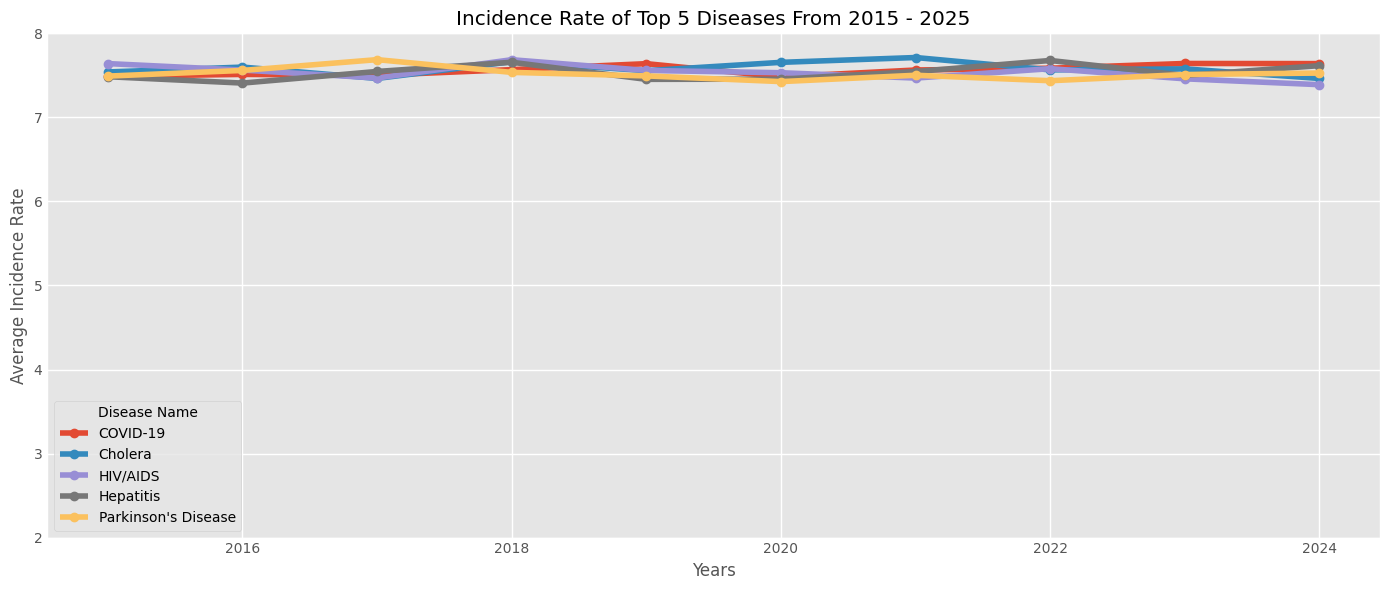

In [27]:
pivot_df = df_q1_result.pivot_table(
    index="Year",
    columns="Disease_Name",
    values="Average_Incidence_Rate"
)

plt.figure(figsize=(14,6))

for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], marker="o", label=column)

plt.title("Incidence Rate of Top 5 Diseases From 2015 - 2025")
plt.xlabel("Years")
plt.ylabel("Average Incidence Rate")
plt.legend(title="Disease Name")
plt.ylim(2, 8)


## Question 2

In [28]:
df_q2_result = (
    df_staging.merge(
        df_top_diseases,
        on = 'Disease_Name',
        how='inner'
    )
    .query('2015 <= Year <= 2025')
    .groupby(['Disease_Name', 'Year'])['Mortality_Rate']
    .mean()
    .reset_index(name='Average_Mortality_Rate')
    .sort_values(by=['Disease_Name', 'Year'], ascending=[True, True])
)

print(df_q2_result)

           Disease_Name  Year  Average_Mortality_Rate
0              COVID-19  2015                5.018992
1              COVID-19  2016                5.111258
2              COVID-19  2017                5.055008
3              COVID-19  2018                5.074749
4              COVID-19  2019                5.147939
5              COVID-19  2020                4.978230
6              COVID-19  2021                5.030601
7              COVID-19  2022                4.959837
8              COVID-19  2023                5.012232
9              COVID-19  2024                5.054713
10              Cholera  2015                5.006339
11              Cholera  2016                5.101424
12              Cholera  2017                5.041795
13              Cholera  2018                5.060746
14              Cholera  2019                4.996527
15              Cholera  2020                5.132932
16              Cholera  2021                5.060510
17              Cholera  202

### creating plot

(2.0, 8.0)

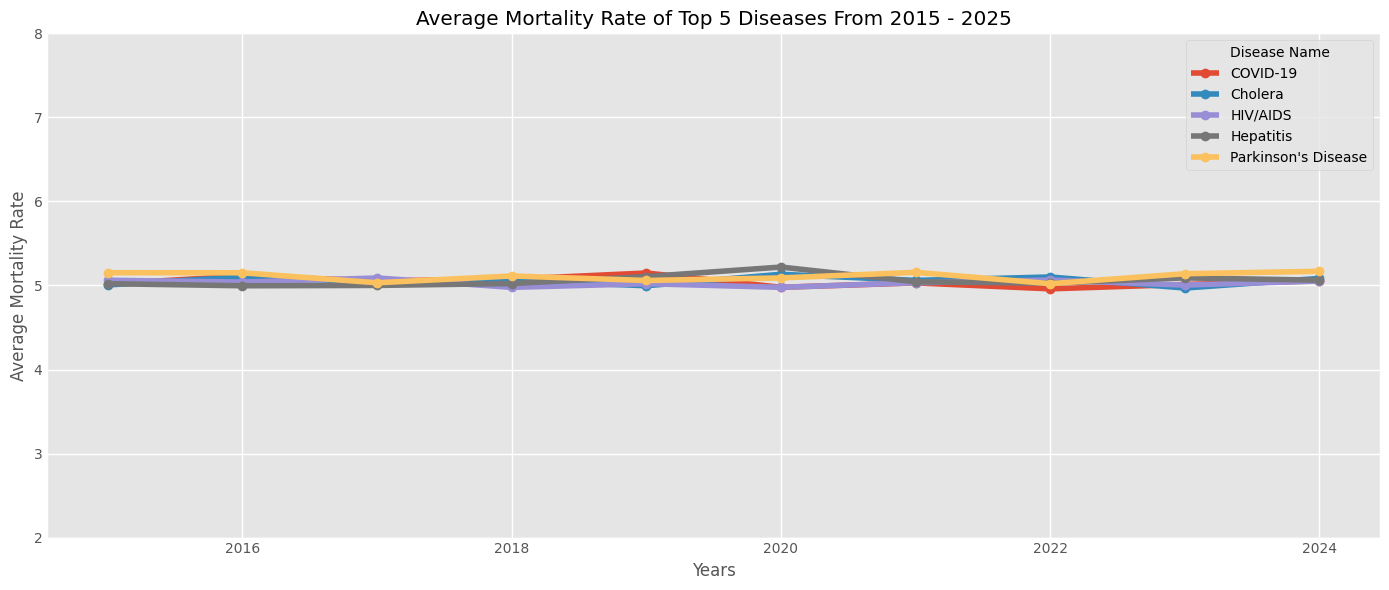

In [29]:
pivot_df = df_q2_result.pivot_table(
    index="Year",
    columns="Disease_Name",
    values="Average_Mortality_Rate"
)

plt.figure(figsize=(14,6))

for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], marker="o", label=column)

plt.title("Average Mortality Rate of Top 5 Diseases From 2015 - 2025")
plt.xlabel("Years")
plt.ylabel("Average Mortality Rate")
plt.legend(title="Disease Name")
plt.ylim(2, 8)

## question 3

In [38]:
cte_query = """
SELECT 
        a.Country, 
        a.Disease_Name, 
        MAX(CASE WHEN CAST(a.Year AS INTEGER) = 2014 THEN a.Mortality_Rate END) AS Rate_2014,
        MAX(CASE WHEN CAST(a.Year AS INTEGER) = 2024 THEN a.Mortality_Rate END) AS Rate_2024
    FROM StagingHealthData a
    JOIN Top_Diseases b ON a.Disease_Name = b.Disease_Name
    GROUP BY a.Country, a.Disease_Name;
"""
q3_df = pd.read_sql_query(cte_query, conn)

q3_df['Total_Rate_Decrease'] = (((q3_df['Rate_2014'] - q3_df['Rate_2024'])/q3_df['Rate_2014'])*100)
top_improvers = q3_df.sort_values(by='Total_Rate_Decrease', ascending=False)
# remove values where there are negative numbers
top_improvers = top_improvers[top_improvers['Total_Rate_Decrease'] > 0]

print(top_improvers[['Country', 'Disease_Name','Total_Rate_Decrease']])

         Country         Disease_Name  Total_Rate_Decrease
5      Australia             COVID-19             2.311558
30       Germany             COVID-19             2.300000
41     Indonesia              Cholera             1.909548
21         China              Cholera             1.703407
25        France             COVID-19             1.503006
54         Japan  Parkinson's Disease             1.407035
85        Turkey             COVID-19             1.310484
74  Saudi Arabia  Parkinson's Disease             1.306533
60       Nigeria             COVID-19             1.302605
95           USA             COVID-19             1.300000
7      Australia             HIV/AIDS             1.212121
59        Mexico  Parkinson's Disease             1.201201
19        Canada  Parkinson's Disease             1.201201
61       Nigeria              Cholera             1.106640
40     Indonesia             COVID-19             1.105528
99           USA  Parkinson's Disease             1.1011

### Let's take a closer look at which diseases have decreased the most over the 10-year time span.

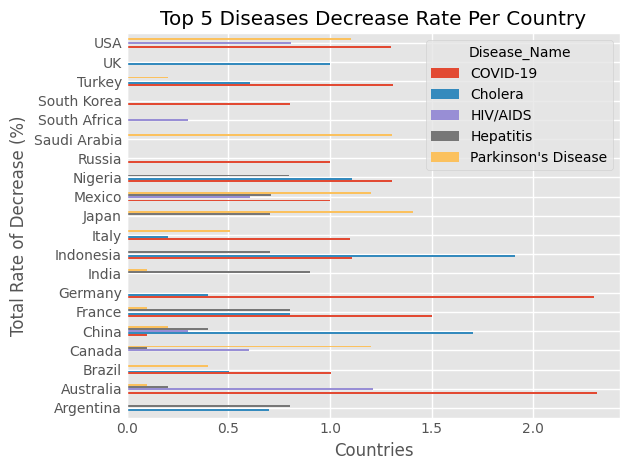

In [48]:

# which countries had the lowest decrease rate?
pivot_df_bar = top_improvers.pivot_table(
    index="Country",
    columns="Disease_Name",
    values="Total_Rate_Decrease",
    aggfunc="sum"
)

ax = pivot_df_bar.plot(kind="barh")
ax.set_title("Top 5 Diseases Decrease Rate Per Country")
ax.set_xlabel("Countries")
ax.set_ylabel("Total Rate of Decrease (%)")
plt.tight_layout()
plt.show()

### diseases that have highest decrease look to be COVID-19, Cholera, and Parkinson's.
### the countries that stand out are Australia, China, Germany, Indonesia, and Japan

### what factors could contribute to decreasing rate?
### what is going right, can it be replicated?

## Question 4

In [49]:
q4_query = """
    SELECT a.Country, a.Disease_Name, Per_Capita_Income, Education_Index, Healthcare_Access
    FROM StagingHealthData a
    JOIN Top_Diseases b
    ON a.Disease_Name = b.Disease_Name
    GROUP BY a.Country, a.Disease_Name
	;
"""
q4_df = pd.read_sql_query(q4_query, conn)

decreased_diseases = ["Cholera", "COVID-19", "Parkinson's Disease"]
q4_df = q4_df[q4_df['Disease_Name'].isin(decreased_diseases)]

standout_countries = ["Australia" , "China", "Germany", "Indonesia", "Japan"]
q4_df = q4_df[q4_df['Country'].isin(standout_countries)]

print(q4_df)

      Country         Disease_Name  Per_Capita_Income  Education_Index  \
5   Australia             COVID-19              14702             0.89   
6   Australia              Cholera              68856             0.90   
9   Australia  Parkinson's Disease              61135             0.55   
20      China             COVID-19              75179             0.45   
21      China              Cholera              53106             0.83   
24      China  Parkinson's Disease              53838             0.89   
30    Germany             COVID-19              57702             0.51   
31    Germany              Cholera              45540             0.71   
34    Germany  Parkinson's Disease              65837             0.78   
40  Indonesia             COVID-19               3910             0.69   
41  Indonesia              Cholera              48252             0.60   
44  Indonesia  Parkinson's Disease              49336             0.49   
50      Japan             COVID-19    

### look at countries with highest per-capita income
### and highest education

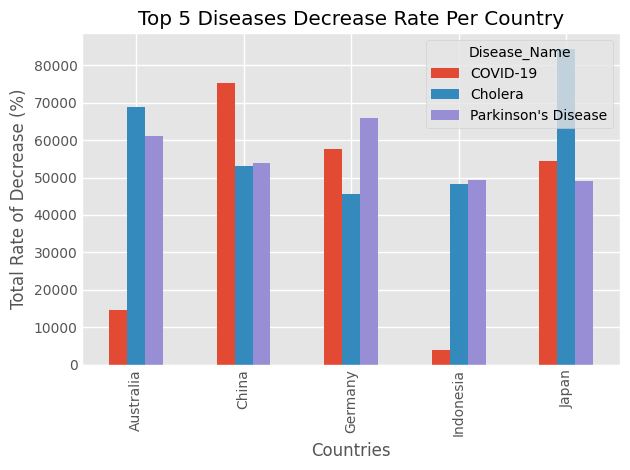

In [53]:
# # grouped bar chart
# species = ("Adelie", "Chinstrap", "Gentoo")
# penguin_means = {
#     'Bill Depth': (18.35, 18.43, 14.98),
#     'Bill Length': (38.79, 48.83, 47.50),
#     'Flipper Length': (189.95, 195.82, 217.19),
# }

# fig, ax = plt.subplots(layout='constrained')

# res = ax.grouped_bar(penguin_means, tick_labels=species, group_spacing=1)
# for container in res.bar_containers:
#     ax.bar_label(container, padding=3)

# # Add some text for labels, title, etc.
# ax.set_ylabel('Length (mm)')
# ax.set_title('Penguin attributes by species')
# ax.legend(loc='upper left', ncols=3)
# ax.set_ylim(0, 250)

# plt.show()

pivot_df_grouped_bar = q4_df.pivot_table(
    index="Country",
    columns="Disease_Name",
    values="Per_Capita_Income",
    aggfunc="sum"
)

ax = pivot_df_grouped_bar.plot(kind="bar")
ax.set_title("Top 5 Diseases Decrease Rate Per Country")
ax.set_xlabel("Countries")
ax.set_ylabel("Total Rate of Decrease (%)")
plt.tight_layout()
plt.show()